# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [1]:
# %conda install -c conda-forge tensorflow opencv matplotlib
# %conda list

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose

2025-12-07 16:36:41.221964: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-07 16:36:43.556064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765121803.702102 1978602 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765121803.817361 1978602 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765121805.758109 1978602 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
#check gpu availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


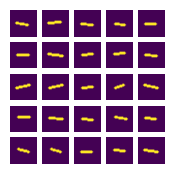

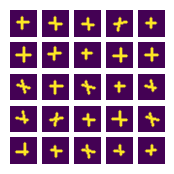

In [4]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [5]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #3756

X_text: "18+78" = y_text: "96 "


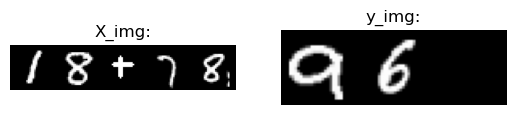

Query #6415

X_text: "32-7 " = y_text: "25 "


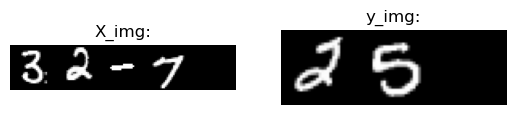

Query #458

X_text: "2+29 " = y_text: "31 "


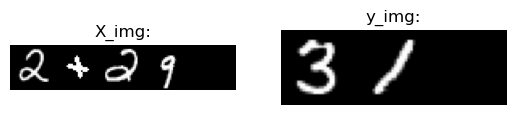

Query #850

X_text: "4+25 " = y_text: "29 "


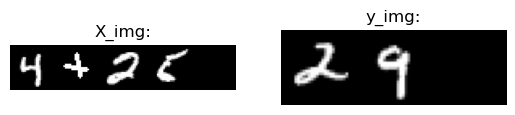

Query #3420

X_text: "17+10" = y_text: "27 "


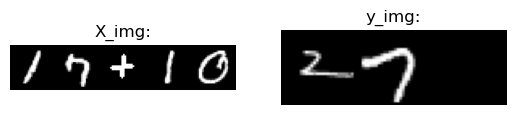

Query #4372

X_text: "21+86" = y_text: "107"


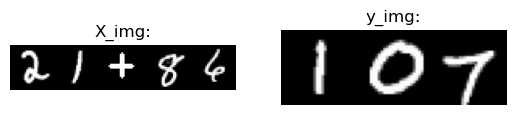

Query #1985

X_text: "9-92 " = y_text: "-83"


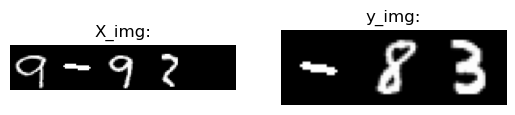

Query #8150

X_text: "40+75" = y_text: "115"


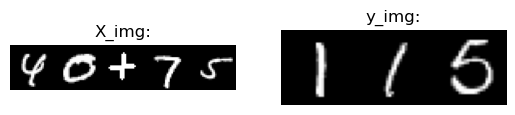

Query #9125

X_text: "45-62" = y_text: "-17"


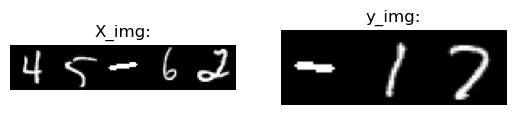

Query #3441

X_text: "17-20" = y_text: "-3 "


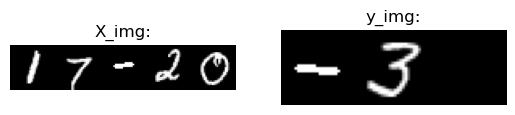

In [6]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [7]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([unique_characters[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)
print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [8]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

n the text-to-text scenario, we are not interested in “memorizing” the whole addition/subtraction
table (about 20,000 strings in total); instead, we want the network to learn some general principles
behind these arithmetic operations. Therefore you should try multiple different splits for your training
and test sets (50% train - 50% test; 25% train - 75% test, 10% train, 90% test etc.) and evaluate the
accuracy and generalization capability of your models. Compare the outputs of your trained networks
to the true labels, and find out what kind of mistakes your models make on the misclassified samples.
Visualize these differences and try to explain them

In [9]:
# ## Your code (look at the assignment description for your tasks for text-to-text model):
# ## Your first task is to fit the text2text model using X_text and y_text)
# splits = [0.50, 0.25, 0.10]
# results = {}
# for i in range(len(splits)):
#     csv_logger = tf.keras.callbacks.CSVLogger(f'text2text_training_log_split_{splits[i]}.csv', append=False)
#     X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=splits[i], random_state=42)
#     print(X_train.shape)
#     model = build_text2text_model()
#     model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test),callbacks=[csv_logger])
#     print(f"Train size: {X_train.shape[0]}")
#     results[splits[i]]= model.evaluate(X_test, y_test)
#     model.save(f'text2text_model_split_{splits[i]}.keras')


In [10]:
# #write results to file
# with open('text2text_results.txt', 'w') as f:
#     for split, result in results.items():
#         f.write(f'Split: {split}, Test Loss: {result[0]}, Test Accuracy: {result[1]}\n')

Compare the outputs of your trained networks
to the true labels, and find out what kind of mistakes your models make on the misclassified samples.
Visualize these differences and try to explain them

In [11]:
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.model_selection import train_test_split
# splits = [0.50, 0.25, 0.10]

# for split in splits:
#     model = tf.keras.models.load_model(f'text2text_model_split_{split}.keras')
#     X_text_onehot_train, X_text_onehot_test, \
#     y_text_onehot_train, y_text_onehot_test, \
#     X_img_train, X_img_test = train_test_split(
#         X_text_onehot,      # The one-hot text queries
#         y_text_onehot,      # The one-hot text answers
#         X_img,              # The image queries
#         test_size=split,
#         random_state=42
#     )

#     y_pred = model.predict(X_text_onehot_test)
#     y_pred_decoded = decode_labels(y_pred)
#     y_test_decoded = decode_labels(y_text_onehot_test)

#     misclassified_indices = [i for i in range(len(y_test_decoded)) if y_test_decoded[i] != y_pred_decoded[i]]

#     print(f'--- Misclassified samples for {split} split ---')
#     mistakes = []
#     # Show first 5 misclassified samples
#     for idx in misclassified_indices:


#         query_str = decode_labels(X_text_onehot_test[idx:idx+1])[0]

#         query_images = X_img_test[idx]

#         # print(f'Input: "{query_str}", True: "{y_test_decoded[idx]}", Predicted: "{y_pred_decoded[idx]}"')
#         mistakes.append((y_test_decoded[idx], y_pred_decoded[idx]))

#         # plt.figure(figsize=(4,2))
#         # plt.axis('off')
#         # plt.title(f'Actual Query Images for "{query_str}"')
#         # plt.imshow(np.hstack(query_images), cmap='gray')
#         # plt.show()
#     #classify multiple types of mistakes:
#     # type1:n -n = -,
#     # type2: n - m = p where p-(n-m) = 1 or 10 or 100
#     #type 3: n + m = p where p-(n+m) != 1 or 10 or 100
#     mistakes_count = {'type1':0, 'type2':0, 'type3':0}
#     for mistake in mistakes:
#         true_answer, predicted_answer = mistake
#         true_answer = true_answer.strip()
#         predicted_answer = predicted_answer.strip()
#         if predicted_answer == '-':
#             mistakes_count['type1'] += 1
#         elif abs(int(predicted_answer)-int(true_answer)) in [1,10,100]:
#             mistakes_count['type2'] += 1
#         else:
#             mistakes_count['type3'] += 1
#             print(predicted_answer, true_answer)

#     print(f'Mistake types for split {split}: {mistakes_count}, total mistakes: {len(misclassified_indices)}')
#     print(mistakes)



---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

In [12]:
## Your code


---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

Version 1

In [ ]:
from tensorflow.keras import layers
def build_text2image_model():

    image_generator = tf.keras.Sequential([
        layers.InputLayer(input_shape=(256,)),

        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')
    ], name="image_generator")

    text2image = tf.keras.Sequential()

    text2image.add(LSTM(256, input_shape=(None,13),dropout=0.05, recurrent_dropout= 0.05))

    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
    text2image.summary()
    return text2image

improved v1

In [51]:

from tensorflow.keras import layers
def build_text2image_model():

    image_generator = tf.keras.Sequential([
        layers.InputLayer(input_shape=(256,)),

        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),

        layers.Conv2DTranspose(64, (5, 5), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),

        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
                layers.BatchNormalization(),
                layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')
    ], name="image_generator")

    text2image = tf.keras.Sequential()

    text2image.add(layers.Bidirectional(
    layers.LSTM(256, return_sequences=False, dropout=0.05)
))
    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
    text2image.summary()
    return text2image

version 2: attempt at mixed loss

In [43]:
from tensorflow.keras import layers, losses
def mae_ssim_loss(y_true, y_pred):
    y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
    y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])
    #binary_crossentropy
    # bc = losses.binary_crossentropy(y_true_reshaped, y_pred_reshaped)


    # bc_loss_flat = tf.reduce_mean(bc, axis=[1, 2])
    #MAE
    mae = losses.MeanAbsoluteError(y_true_reshaped, y_pred_reshaped)
    bc_loss_flat = tf.reduce_mean(mae, axis=[1, 2])
    # SSIM (structural loss)

    ssim_scores = tf.image.ssim(y_true_reshaped, y_pred_reshaped, max_val=1.0)
    ssim_loss_flat = 1.0 - ssim_scores

    # Combine the losses
    mse_weight = 0.5
    ssim_weight = 0.5

    combined_loss = (mse_weight * bc_loss_flat) + (ssim_weight * ssim_loss_flat)
    return combined_loss

#seperate variant for monitoring both losses.
def ssim_metric(y_true, y_pred):

    y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
    y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])

    ssim_scores = tf.image.ssim(y_true_reshaped, y_pred_reshaped, max_val=2.0)


    return tf.reduce_mean(ssim_scores)


# def mse_metric(y_true, y_pred):

#     y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
#     y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])


#     mse = losses.mean_squared_error(y_true_reshaped, y_pred_reshaped)


#     return tf.reduce_mean(mse)

In [16]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, LSTM, InputLayer
)
from tensorflow.keras.models import Model, Sequential

In [38]:
from tensorflow.keras import layers
def build_text2image_2_model(embedding_dim):

    image_generator = tf.keras.Sequential([

        layers.InputLayer(input_shape=(256,)),

        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2D(1, (3, 3), padding='same', activation='tanh')
    ], name="image_generator")

    text2image = tf.keras.Sequential()

    text2image.add(LSTM(256, input_shape=(None,13),dropout=0.05, recurrent_dropout= 0.05))

    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss=bce_ssim_loss, optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       metrics=[ssim_metric])
    text2image.summary()
    return text2image


version 3 (extra lstm)

In [46]:
from tensorflow.keras import layers
def build_text2image_3_model(embedding_dim):

    image_generator = tf.keras.Sequential([

        layers.InputLayer(input_shape=(256,)),

        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2D(1, (3, 3), padding='same', activation='tanh')
    ], name="image_generator")

    text2image = tf.keras.Sequential()
    text2image.add(layers.LSTM(256,
                               input_shape=(None, len(unique_characters)),
                               return_sequences=True,
                               dropout=0.05,
                               recurrent_dropout=0.05))
    text2image.add(layers.LSTM(256,
                               return_sequences=False,
                               dropout=0.05,
                               recurrent_dropout=0.05))
    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
    text2image.summary()
    return text2image


evaluator model 

In [19]:
def build_sequence_evaluator(num_classes=13, sequence_length=3):
    cnn_extractor = cnn_extractor = Sequential([
        InputLayer(shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten()
    ], name="cnn_extractor")

    model = Sequential([
        InputLayer(shape=(sequence_length, 28, 28, 1)),
        TimeDistributed(cnn_extractor),
        LSTM(128, return_sequences=True),
        TimeDistributed(Dense(num_classes, activation='softmax'))
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    model.summary()
    return model
evaluator = build_sequence_evaluator()

I0000 00:00:1765121924.767900 1978602 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6070 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 3, 3136)        │        18,816 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 3, 128)         │     1,671,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 3, 13)          │         1,677 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,692,173 (6.46 MB)

 Trainable params: 1,692,173 (6.46 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:

X_text_train, X_text_test, \
y_text_train, y_text_test, \
X_img_train, X_img_test, \
y_img_train, y_img_test = train_test_split(
        X_text_onehot,      # The one-hot text queries
        y_text_onehot,      # The one-hot text answers
        X_img,              # The image queries
        y_img,              # The image answers
        test_size=0.1,
        random_state=42
    )
X_text_train, X_text_valid, \
y_text_train, y_text_valid, \
X_img_train, X_img_valid, \
y_img_train, y_img_valid  = train_test_split(
        X_text_train,      # The one-hot text queries
        y_text_train,      # The one-hot text answers
        X_img_train,       # The image queries
        y_img_train,       # The image answers
        test_size=0.1,
        random_state=42
    )

In [32]:
char_to_index = {char: i for i, char in enumerate(unique_characters)}
index_to_char = {i: char for char, i in char_to_index.items()}
def decode_labels_from_integers(integer_data):
    decoded_strings = []

    for sequence in integer_data:
        current_string = ""
        for index in sequence:
            char = index_to_char.get(index)
            if char:
                current_string += char

        decoded_strings.append(current_string)

    return decoded_strings

In [53]:
class EvaluatorCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, evaluator_model, relevant_indices=[0, 1, 2]):
        """
        relevant_indices: The positions in the sequence that matter.
                          e.g., [0, 1, 2] for [Size, Color, Shape, Pad, Pad]
        """
        super(EvaluatorCallback, self).__init__()
        self.X_val = validation_data[0]
        self.y_val = validation_data[1]
        self.evaluator = evaluator_model
        self.indices = relevant_indices

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        generated_images = self.model.predict(self.X_val, verbose=0)
        # #show images
        # X_text_decoded=(decode_labels_from_integers(np.argmax(X_text_valid, axis=2)))
        # for i in range(5):
        #     plt.figure(figsize=(4,2))
        #     plt.axis('off')
        #     print(X_text_decoded[i])
        #     plt.title(f'{X_text_decoded[i]}={eval(X_text_decoded[i])}')
        #     plt.imshow(np.hstack(generate_images[i]), cmap='gray')
        #     plt.show()
        probs = self.evaluator.predict(generated_images, verbose=0)

        pred_sequences = np.argmax(probs, axis=-1)


        if len(self.X_val.shape) == 3:

            true_sequences = np.argmax(self.y_val, axis=-1)
        else:

            true_sequences = self.y_val
        # print(f"\n\n--- DEBUG EPOCH {epoch+1} ---")
        # print(f"Predicted [0]: {pred_sequences[0]}")
        # print(f"True      [0]: {true_sequences[0]}")
        # print(f"Predicted [1]: {pred_sequences[1]}")
        # print(f"True      [1]: {true_sequences[1]}")
        # print("-----------------------")

        pred_relevant = pred_sequences[:, self.indices]
        true_relevant = true_sequences[:, self.indices]


        char_matches = (pred_relevant == true_relevant)
        avg_char_acc = np.mean(char_matches)


        seq_matches = np.all(char_matches, axis=1)
        strict_acc = np.mean(seq_matches)


        relevant_probs = np.max(probs, axis=-1)[:, self.indices]
        avg_conf = np.mean(relevant_probs)

        # print
        print(f"\n[Epoch {epoch+1}] Strict Acc: {strict_acc:.4f} | Char Acc: {avg_char_acc:.4f} | Conf: {avg_conf:.4f}")

        logs['eval_strict_acc'] = strict_acc
        logs['eval_char_acc'] = avg_char_acc
        logs['eval_conf'] = avg_conf

In [22]:
evaluator = build_sequence_evaluator(num_classes=len(unique_characters))
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=4,
    min_lr=1e-6,
    verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7
)
evaluator.fit(
    y_img_train, y_text_train,
    epochs=100,
    batch_size=64,
    validation_data=(y_img_valid, y_text_valid),
    callbacks=[early_stopper, lr_scheduler]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 3, 3136)        │        18,816 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 128)         │     1,671,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 3, 13)          │         1,677 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,692,173 (6.46 MB)

 Trainable params: 1,692,173 (6.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1765121937.401697 1984662 cuda_dnn.cc:529] Loaded cuDNN version 91002


254/254 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9056 - loss: 0.3368 - val_accuracy: 0.9794 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9843 - loss: 0.0584 - val_accuracy: 0.9867 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9907 - loss: 0.0355 - val_accuracy: 0.9898 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9941 - loss: 0.0237 - val_accuracy: 0.9919 - val_loss: 0.0275 - learning_rate: 0.0010
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9965 - loss: 0.0158 - val_accuracy: 0.9939 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9974 - loss: 0.0121 - val_accuracy: 0.9926 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 7/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9985 - loss: 0.0079 - val

In [52]:
model1 = build_text2image_model()


lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=4,
    min_lr=1e-6,
    verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7
)
csv_logger = tf.keras.callbacks.CSVLogger(
    filename='trainingoutput.csv'
)
eval_callback = EvaluatorCallback(
    validation_data=(X_text_valid, y_text_valid),
    evaluator_model=evaluator
)
model1.fit(X_text_train, y_img_train, epochs=50, batch_size=64,
           validation_data=(X_text_valid, y_img_valid),
           callbacks=[lr_scheduler, early_stopper, csv_logger,eval_callback])


/vol/home/s3328007/.conda/envs/idl2/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_12 (RepeatVector) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,323,905 (16.49 MB)

 Trainable params: 4,298,305 (16.40 MB)

 Non-trainable params: 25,600 (100.00 KB)

Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3668

--- DEBUG EPOCH 1 ---
Predicted [0]: [11  3 12]
True      [0]: [11  3  6]
Predicted [1]: [11  4 12]
True      [1]: [11  4  8]
-----------------------

[Epoch 1] Strict Acc: 0.0072 | Char Acc: 0.3776 | Conf: 0.7412
254/254 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - loss: 0.2752 - val_loss: 0.2176 - learning_rate: 1.0000e-04 - eval_strict_acc: 0.0072 - eval_char_acc: 0.3776 - eval_conf: 0.7412
Epoch 2/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2132

--- DEBUG EPOCH 2 ---
Predicted [0]: [11  8  8]
True      [0]: [11  3  6]
Predicted [1]: [11  8 12]
True      [1]: [11  4  8]
-----------------------

[Epoch 2] Strict Acc: 0.0072 | Char Acc: 0.3717 | Conf: 0.7894
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 0.2097 - val_loss: 0.2039 - learning_rate: 1.0000e-04 - eval_strict_acc: 0.0072 - eval_char_acc: 0.3717 - eval_conf: 0.7894
Epoch 3/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2039

--- DEBUG EPOCH

In [24]:
# unique_characters = '0123456789+- '
char_to_index = {char: i for i, char in enumerate(unique_characters)}
index_to_char = {i: char for char, i in char_to_index.items()}
def decode_labels_from_integers(integer_data):
    decoded_strings = []

    for sequence in integer_data:
        current_string = ""
        for index in sequence:
            char = index_to_char.get(index)
            if char:
                current_string += char

        decoded_strings.append(current_string)

    return decoded_strings

 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20-56


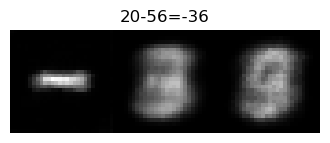

29-77


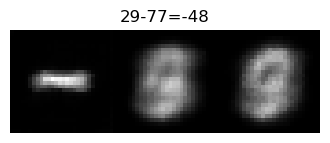

15+95


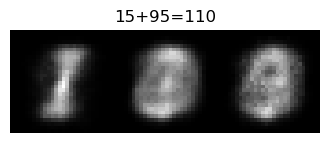

84-75


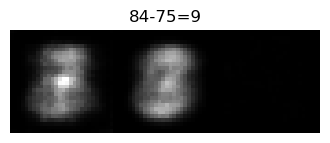

82-81


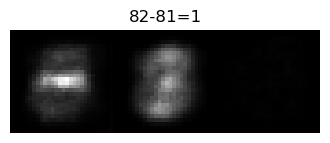

76-91


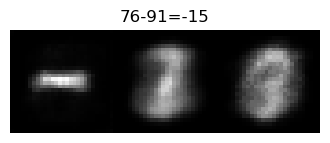

15-84


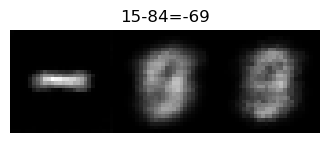

57+99


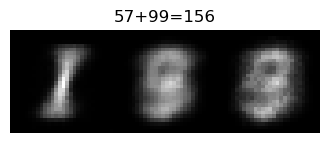

17-82


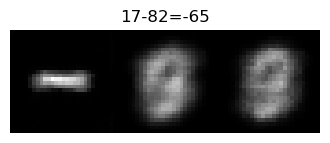

20-5 


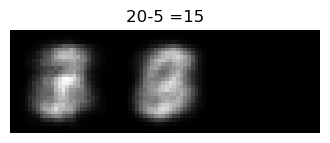

29-75


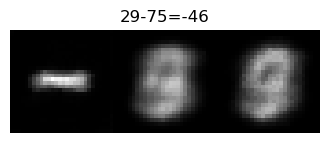

7-58 


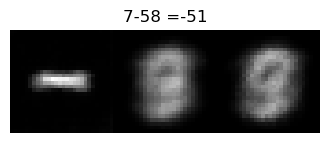

25-38


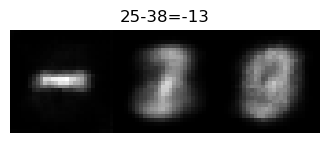

67+54


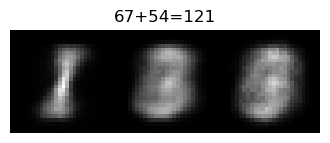

98-75


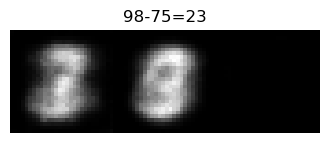

71-49


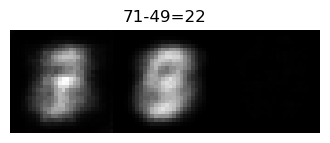

12+76


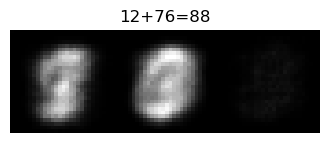

8+43 


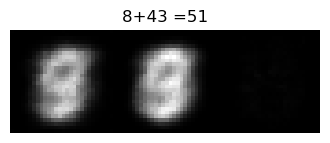

73+54


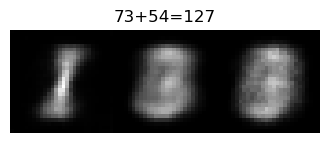

22-98


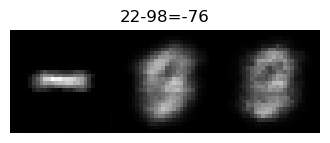

In [50]:

gen_y = model1.predict(X_text_valid)
X_text_decoded=(decode_labels_from_integers(np.argmax(X_text_valid, axis=2)))
for i in range(20):
    plt.figure(figsize=(4,2))
    plt.axis('off')
    print(X_text_decoded[i])
    plt.title(f'{X_text_decoded[i]}={eval(X_text_decoded[i])}')
    plt.imshow(np.hstack(gen_y[i]), cmap='gray')
    plt.show()

In [44]:
csv_logger = tf.keras.callbacks.CSVLogger(
    filename='trainingoutput_model2.csv'
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=4,
    min_lr=1e-6,
    verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7
)
model2 = build_text2image_2_model(embedding_dim=50)
model2.fit(X_text_train, y_img_train, epochs=50, batch_size=64,
           validation_data=(X_text_valid, y_img_valid),
           callbacks=[lr_scheduler, early_stopper, csv_logger,eval_callback])

/vol/home/s3328007/.conda/envs/idl2/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/vol/home/s3328007/.conda/envs/idl2/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_9 (RepeatVector)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 3, 28, 28, 1)   │     1,723,553 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,525,345 (9.63 MB)

 Trainable params: 2,512,609 (9.58 MB)

 Non-trainable params: 12,736 (49.75 KB)

Epoch 1/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9836 - ssim_metric: 0.0230

--- DEBUG EPOCH 1 ---
Predicted [0]: [3 4 4]
True      [0]: [11  3  6]
Predicted [1]: [8 8 8]
True      [1]: [11  4  8]
-----------------------

[Epoch 1] Strict Acc: 0.0006 | Char Acc: 0.0946 | Conf: 0.7310
254/254 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.8712 - ssim_metric: 0.0351 - val_loss: 0.7172 - val_ssim_metric: 0.0509 - learning_rate: 1.0000e-04 - eval_strict_acc: 5.5556e-04 - eval_char_acc: 0.0946 - eval_conf: 0.7310
Epoch 2/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7327 - ssim_metric: 0.0544

--- DEBUG EPOCH 2 ---
Predicted [0]: [ 8  3 12]
True      [0]: [11  3  6]
Predicted [1]: [ 8  8 12]
True      [1]: [11  4  8]
-----------------------

[Epoch 2] Strict Acc: 0.0022 | Char Acc: 0.1541 | Conf: 0.7435
254/254 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.7098 - ssim_metric: 0.0575 - val_loss: 0.6761 - val_ssim_metric: 0.0595 - learning_rate: 1.0000e-04 - eval_strict_acc

KeyboardInterrupt: 

In [27]:
model3 = build_text2image_3_model(embedding_dim=50)
model3.fit(X_text_train, y_img_train, epochs=50, batch_size=64,
           validation_data=(X_text_valid, y_img_valid),
              callbacks=[lr_scheduler, early_stopper, csv_logger,eval_callback])


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, None, 256)      │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 3, 28, 28, 1)   │     1,723,553 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,657 (11.64 MB)

 Trainable params: 3,037,921 (11.59 MB)

 Non-trainable params: 12,736 (49.75 KB)

Epoch 1/50


254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8478

--- DEBUG EPOCH 1 ---
Predicted [0]: [ 2 12 12]
True      [0]: [11  3  6]
Predicted [1]: [ 2 12 12]
True      [1]: [11  4  8]
-----------------------

[Epoch 1] Strict Acc: 0.0033 | Char Acc: 0.1750 | Conf: 0.7435
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 0.7369 - val_loss: 0.4979 - learning_rate: 1.0000e-04 - eval_strict_acc: 0.0033 - eval_char_acc: 0.1750 - eval_conf: 0.7435
Epoch 2/50
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5995

--- DEBUG EPOCH 2 ---
Predicted [0]: [2 3 3]
True      [0]: [11  3  6]
Predicted [1]: [ 8 12 12]
True      [1]: [11  4  8]
-----------------------

[Epoch 2] Strict Acc: 0.0022 | Char Acc: 0.1576 | Conf: 0.8020
254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.5732 - val_loss: 0.5273 - learning_rate: 1.0000e-04 - eval_strict_acc: 0.0022 - eval_char_acc: 0.1576 - eval_conf: 0.8020
Epoch 3/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5213

--- DEBUG EPOCH 3 ---
Predicte

15/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20-56


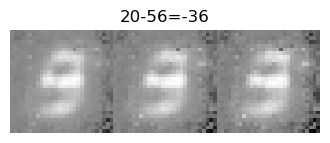

29-77


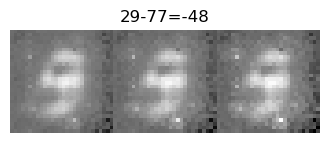

15+95


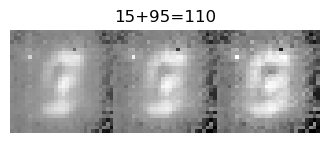

84-75


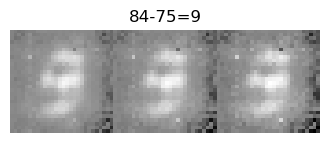

82-81


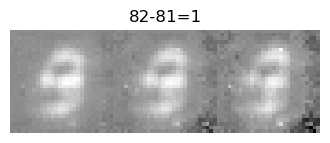

76-91


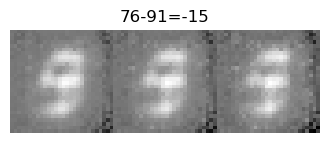

15-84


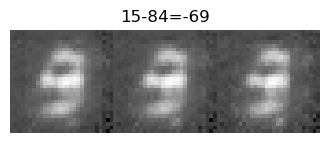

57+99


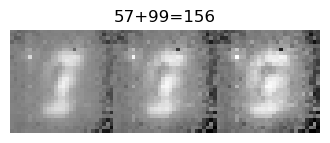

17-82


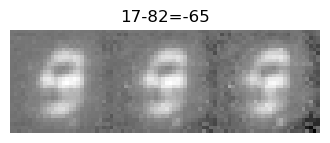

20-5 


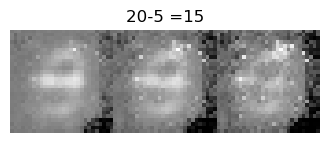

29-75


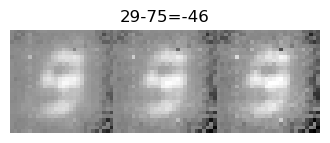

7-58 


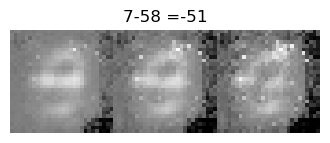

25-38


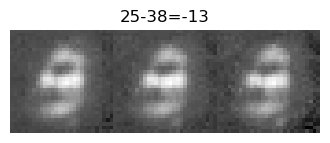

67+54


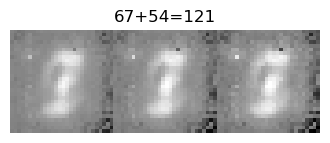

98-75


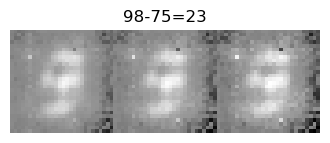

71-49


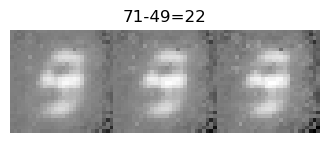

12+76


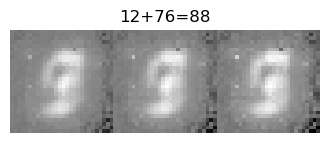

8+43 


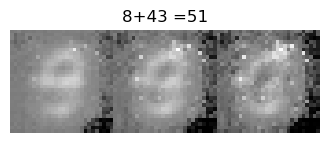

73+54


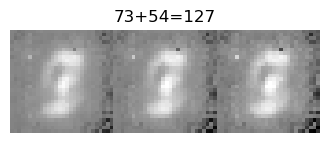

22-98


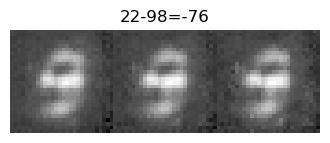

In [45]:

gen_y = model2.predict(X_text_valid)
X_text_decoded=(decode_labels_from_integers(np.argmax(X_text_valid, axis=2)))
for i in range(20):
    plt.figure(figsize=(4,2))
    plt.axis('off')
    print(X_text_decoded[i])
    plt.title(f'{X_text_decoded[i]}={eval(X_text_decoded[i])}')
    plt.imshow(np.hstack(gen_y[i]), cmap='gray')
    plt.show()

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
20-56


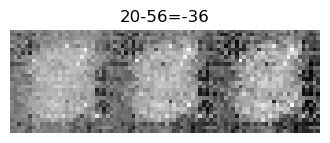

29-77


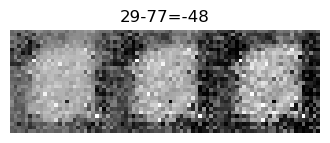

15+95


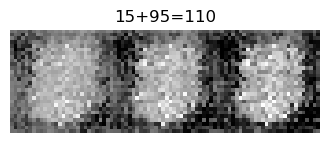

84-75


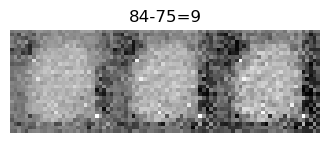

82-81


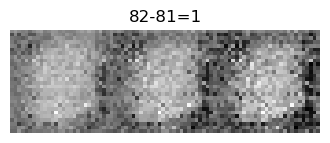

76-91


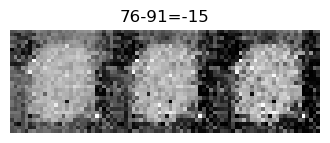

15-84


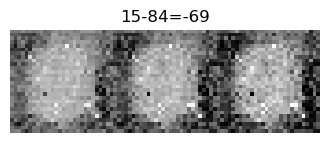

57+99


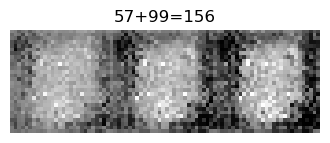

17-82


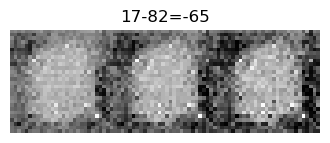

20-5 


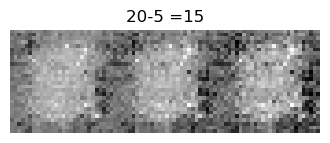

29-75


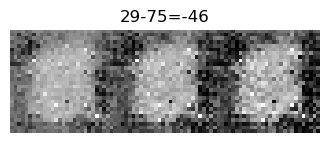

7-58 


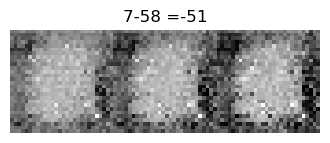

25-38


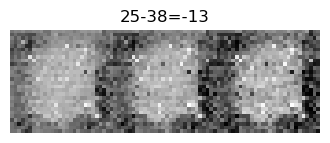

67+54


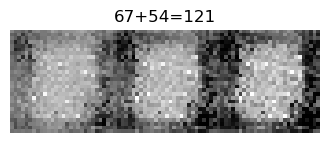

98-75


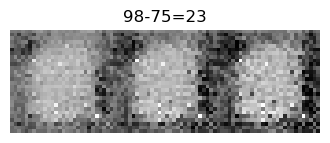

71-49


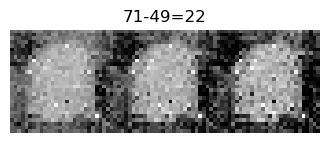

12+76


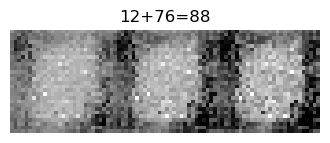

8+43 


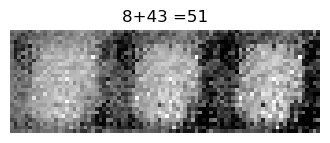

73+54


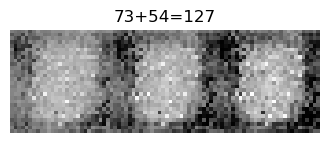

22-98


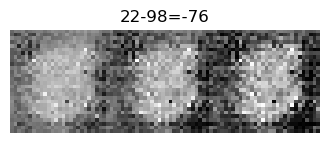

In [28]:

gen_y = model3.predict(X_text_valid)
X_text_decoded=(decode_labels_from_integers(np.argmax(X_text_valid, axis=2)))
for i in range(20):
    plt.figure(figsize=(4,2))
    plt.axis('off')
    print(X_text_decoded[i])
    plt.title(f'{X_text_decoded[i]}={eval(X_text_decoded[i])}')
    plt.imshow(np.hstack(gen_y[i]), cmap='gray')
    plt.show()